<a href="https://colab.research.google.com/github/qfkiwi/empezando/blob/main/proyecto_traata_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#INSTALACION SILENCIOSA
%%capture
!pip install missingno

#importando librerias necesarias

In [ ]:
import pandas as pd #manejo de datos
import numpy as np #operaciones numericas
import missingno as msno #visualizar datos faltantes
import seaborn as sns #graficos estadisticos
import plotly as pl #visualizaciones interactivas

In [ ]:
#cagar dataset
df=pd.read_csv('kiva_loans.csv')

In [ ]:
df.count()

,0
id,671205
funded_amount,671205
loan_amount,671205
activity,671205
sector,671205
use,666973
country_code,671197
country,671205
region,614405
currency,671205


In [ ]:
df.describe()

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,6.712050e+05,671205.000000,671205.000000,657698.000000,671205.000000,671205.000000
mean,9.932486e+05,785.995061,842.397107,178.199616,13.739022,20.590922
std,1.966113e+05,1130.398941,1198.660073,94.247581,8.598919,28.459551
min,6.530470e+05,0.000000,25.000000,9.000000,1.000000,0.000000
25%,8.230720e+05,250.000000,275.000000,126.000000,8.000000,7.000000
50%,9.927800e+05,450.000000,500.000000,145.000000,13.000000,13.000000
75%,1.163653e+06,900.000000,1000.000000,204.000000,14.000000,24.000000
max,1.340339e+06,100000.000000,100000.000000,536.000000,158.000000,2986.000000


In [ ]:
#busqueda de dupes
df.duplicated().sum()

np.int64(0)

In [ ]:
#duplicados
df.isna().sum().sort_values(ascending=False)

,0
tags,171416
region,56800
funded_time,48331
partner_id,13507
use,4232
borrower_genders,4221
disbursed_time,2396
country_code,8
activity,0
loan_amount,0


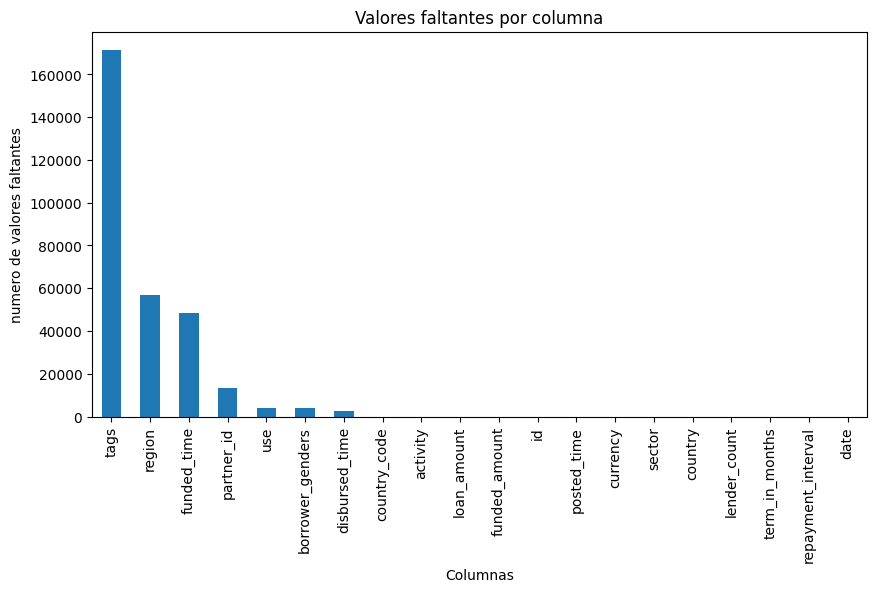

In [ ]:
#verificacion si nulos superan 25%
import matplotlib.pyplot as plt
#calcular% de nulos
missing=df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title('Valores faltantes por columna')
plt.ylabel('numero de valores faltantes')
plt.xlabel('Columnas')
plt.show()

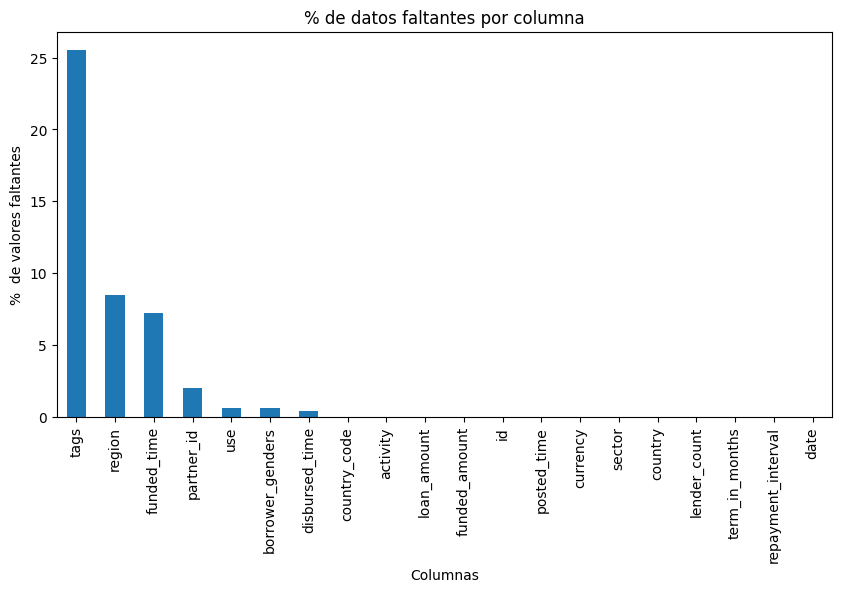

In [ ]:
missing_pct=(df.isna().mean() * 100).sort_values(ascending=False)


plt.figure(figsize=(10,5))
missing_pct.plot(kind='bar')
plt.title('% de datos faltantes por columna')
plt.ylabel('%  de valores faltantes')
plt.xlabel('Columnas')
plt.show()

<Axes: >

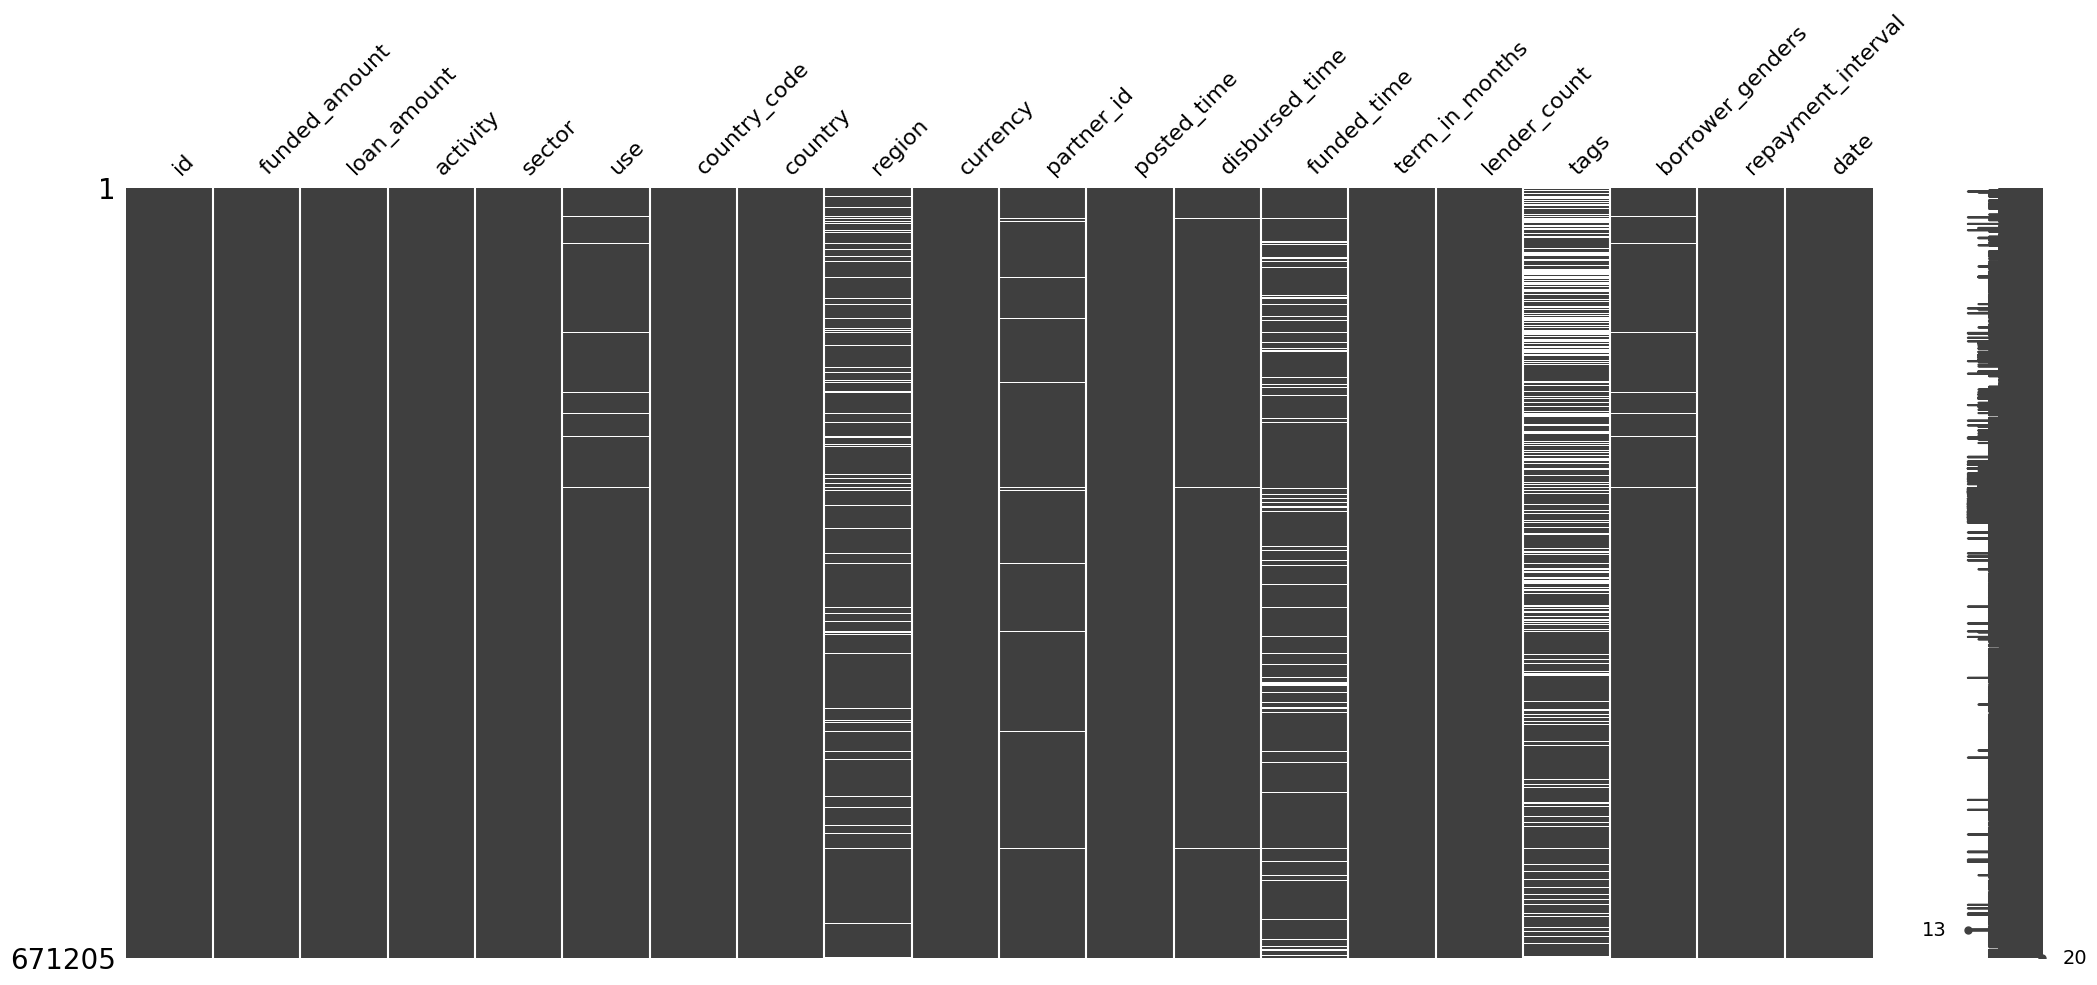

In [ ]:
msno.matrix(df)

<Axes: >

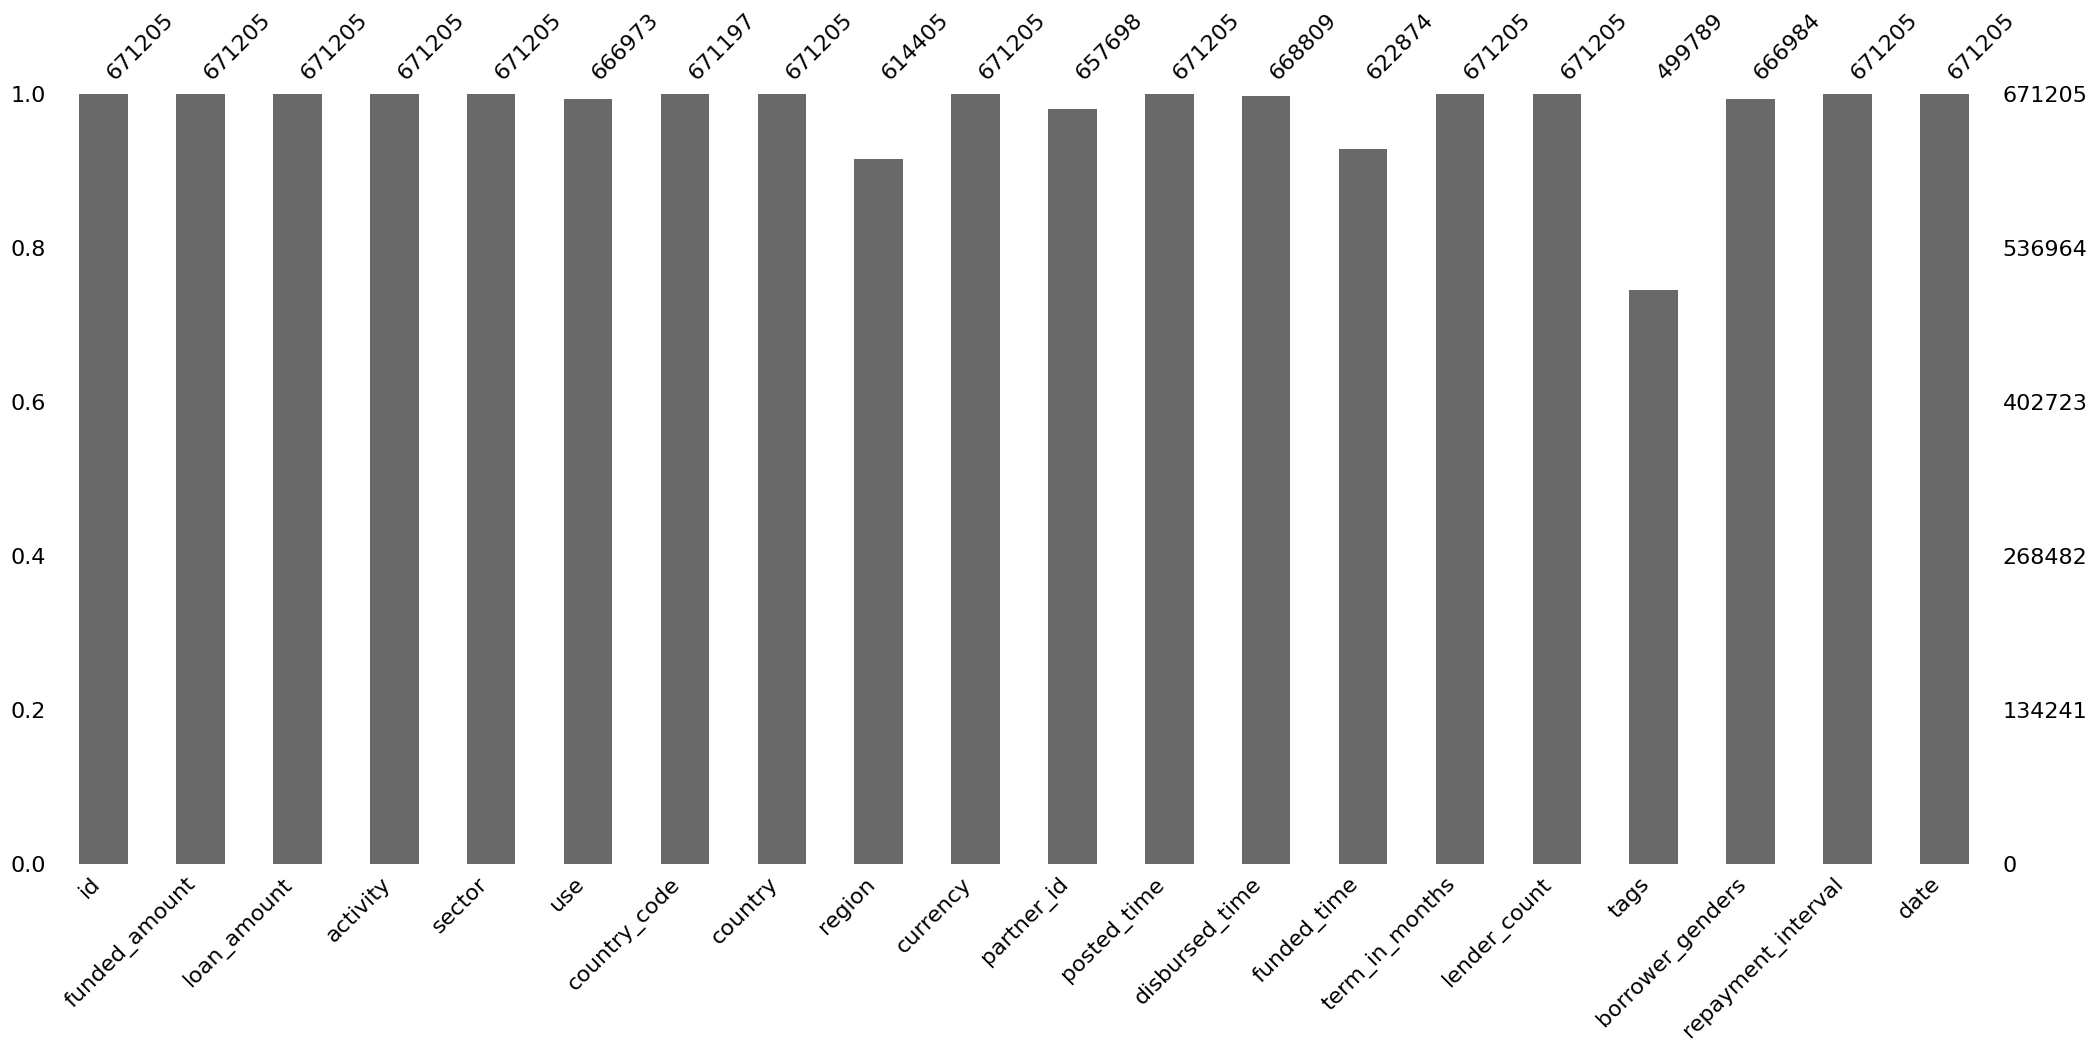

In [ ]:
msno.bar(df)

In [ ]:
kiva_loans_df=df.copy()

In [ ]:
'''
 elimino countr_code porquue ya esta la columna country
 elimino tags porquue tiene muchos valores falatantes
 elimino borrower_genders porquue tiene muchos valores falatantes
 elimino funded_time porque posted_time ya nos devuelve el mismo valor
'''
ctl=['country_code','tags','partner_id','borrower_genders','date','funded_time','region','use']
for col in ctl:
    if col in kiva_loans_df.columns:
       kiva_loans_df = kiva_loans_df.drop(columns=col)


In [ ]:
kiva_loans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   country             671205 non-null  object 
 6   currency            671205 non-null  object 
 7   posted_time         671205 non-null  object 
 8   disbursed_time      668809 non-null  object 
 9   term_in_months      671205 non-null  float64
 10  lender_count        671205 non-null  int64  
 11  repayment_interval  671205 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 61.5+ MB


In [ ]:
#convertir a date time las fechas
kiva_loans_df['posted_time']=pd.to_datetime(kiva_loans_df['posted_time'],errors='coerce')
kiva_loans_df['disbursed_time']=pd.to_datetime(kiva_loans_df['disbursed_time'],errors='coerce')

#noemalizar a la fecha (elimina la hora al ponerla a medianoche)
kiva_loans_df['posted_time']=kiva_loans_df['posted_time'].dt.normalize()
kiva_loans_df['disbursed_time']=kiva_loans_df['disbursed_time'].dt.normalize()

In [ ]:
kiva_loans_df.head(1)

,id,funded_amount,loan_amount,activity,sector,country,currency,posted_time,disbursed_time,term_in_months,lender_count,repayment_interval
0,653051,300.0,300.0,Fruits & Vegetables,Food,Pakistan,PKR,2014-01-01 00:00:00+00:00,2013-12-17 00:00:00+00:00,12.0,12,irregular


# cambio de tipo de dato de object a string

In [ ]:
for col in kiva_loans_df.columns:
  if kiva_loans_df[col].dtype=='object':
    kiva_loans_df[col]=kiva_loans_df[col].astype('string')

# verificacion de datos de columnas

In [ ]:
kiva_loans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  671205 non-null  int64              
 1   funded_amount       671205 non-null  float64            
 2   loan_amount         671205 non-null  float64            
 3   activity            671205 non-null  string             
 4   sector              671205 non-null  string             
 5   country             671205 non-null  string             
 6   currency            671205 non-null  string             
 7   posted_time         671205 non-null  datetime64[ns, UTC]
 8   disbursed_time      668809 non-null  datetime64[ns, UTC]
 9   term_in_months      671205 non-null  float64            
 10  lender_count        671205 non-null  int64              
 11  repayment_interval  671205 non-null  string             
dtypes: datetime64[ns

In [ ]:
def clean(s):
  return s.astype(str).str.strip().str.lower()
for col in kiva_loans_df.columns:
  if kiva_loans_df[col].dtype=='string':
    kiva_loans_df[col]=clean(kiva_loans_df[col])

# clasificacion de prestamos segun fecha de desembolso
##creamos la columna loan_type para saber si un prestamo fue desenbolsado antes o despues de la fecha de publicacion



*   pre_disbursed : desenbolsado antes de publicarse (disbursed_time < posted_time)
*   post_disbursed : desenbolsado despues de publicarse (disbursed_time > posted_time)



In [ ]:
kiva_loans_df['loan_type']=np.where(kiva_loans_df['disbursed_time']<kiva_loans_df['posted_time'],'pre_disbursed','post_disbursed')

In [ ]:
kiva_loans_df.head(5)

,id,funded_amount,loan_amount,activity,sector,country,currency,posted_time,disbursed_time,term_in_months,lender_count,repayment_interval,loan_type
0,653051,300.0,300.0,fruits & vegetables,food,pakistan,pkr,2014-01-01 00:00:00+00:00,2013-12-17 00:00:00+00:00,12.0,12,irregular,pre_disbursed
1,653053,575.0,575.0,rickshaw,transportation,pakistan,pkr,2014-01-01 00:00:00+00:00,2013-12-17 00:00:00+00:00,11.0,14,irregular,pre_disbursed
2,653068,150.0,150.0,transportation,transportation,india,inr,2014-01-01 00:00:00+00:00,2013-12-17 00:00:00+00:00,43.0,6,bullet,pre_disbursed
3,653063,200.0,200.0,embroidery,arts,pakistan,pkr,2014-01-01 00:00:00+00:00,2013-12-24 00:00:00+00:00,11.0,8,irregular,pre_disbursed
4,653084,400.0,400.0,milk sales,food,pakistan,pkr,2014-01-01 00:00:00+00:00,2013-12-17 00:00:00+00:00,14.0,16,monthly,pre_disbursed


In [ ]:
post_loan= kiva_loans_df[kiva_loans_df['loan_type']=='post_disbursed']

In [ ]:
post_loan.head(5)

,id,funded_amount,loan_amount,activity,sector,country,currency,posted_time,disbursed_time,term_in_months,lender_count,repayment_interval,loan_type
5,1080148,250.0,250.0,services,services,kenya,kes,2014-01-01 00:00:00+00:00,2014-01-30 00:00:00+00:00,4.0,6,irregular,post_disbursed
62,653290,4275.0,4275.0,personal housing expenses,housing,vietnam,vnd,2014-01-02 00:00:00+00:00,2014-01-27 00:00:00+00:00,14.0,144,bullet,post_disbursed
67,1080150,125.0,125.0,energy,services,kenya,kes,2014-01-02 00:00:00+00:00,2014-01-30 00:00:00+00:00,3.0,6,irregular,post_disbursed
99,1080153,5000.0,5000.0,food production/sales,food,united states,usd,2014-01-02 00:00:00+00:00,2014-03-10 00:00:00+00:00,30.0,261,monthly,post_disbursed
114,1080151,125.0,125.0,energy,services,kenya,kes,2014-01-02 00:00:00+00:00,2014-01-30 00:00:00+00:00,3.0,7,irregular,post_disbursed


In [ ]:
#obtener min y max reales
min_val=kiva_loans_df['loan_amount'].min()
max_val=kiva_loans_df['loan_amount'].max()

#definir limites segun los rangos
bins = [
    min_val,    #minimo real
    500,
    2500,
    10000,
    max_val     #maximo real
]

label = ['micro','small','medium','large']

kiva_loans_df['loan_amount_category'] = pd.cut(kiva_loans_df['loan_amount'], bins=bins, labels=label,right=False)

#ver resumen
print(kiva_loans_df['loan_amount_category'].value_counts)
print('Min:',min_val,'Max:',max_val)

<bound method IndexOpsMixin.value_counts of 0         micro
1         small
2         micro
3         micro
4         micro
          ...  
671200    micro
671201    micro
671202    micro
671203    micro
671204    micro
Name: loan_amount_category, Length: 671205, dtype: category
Categories (4, object): ['micro' < 'small' < 'medium' < 'large']>
Min: 25.0 Max: 100000.0


#hostograma

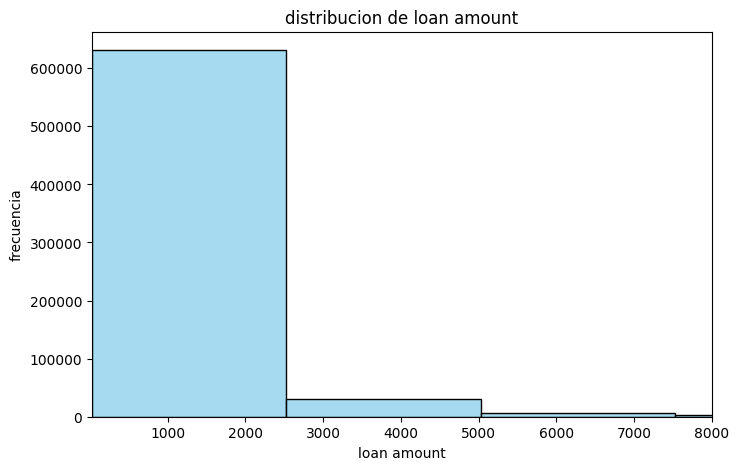

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(kiva_loans_df['loan_amount'],bins=40,kde=False,color='skyblue')
plt.title('distribucion de loan amount')
plt.xlabel('loan amount')
plt.ylabel('frecuencia')
plt.xlim(25,8000)
plt.show()

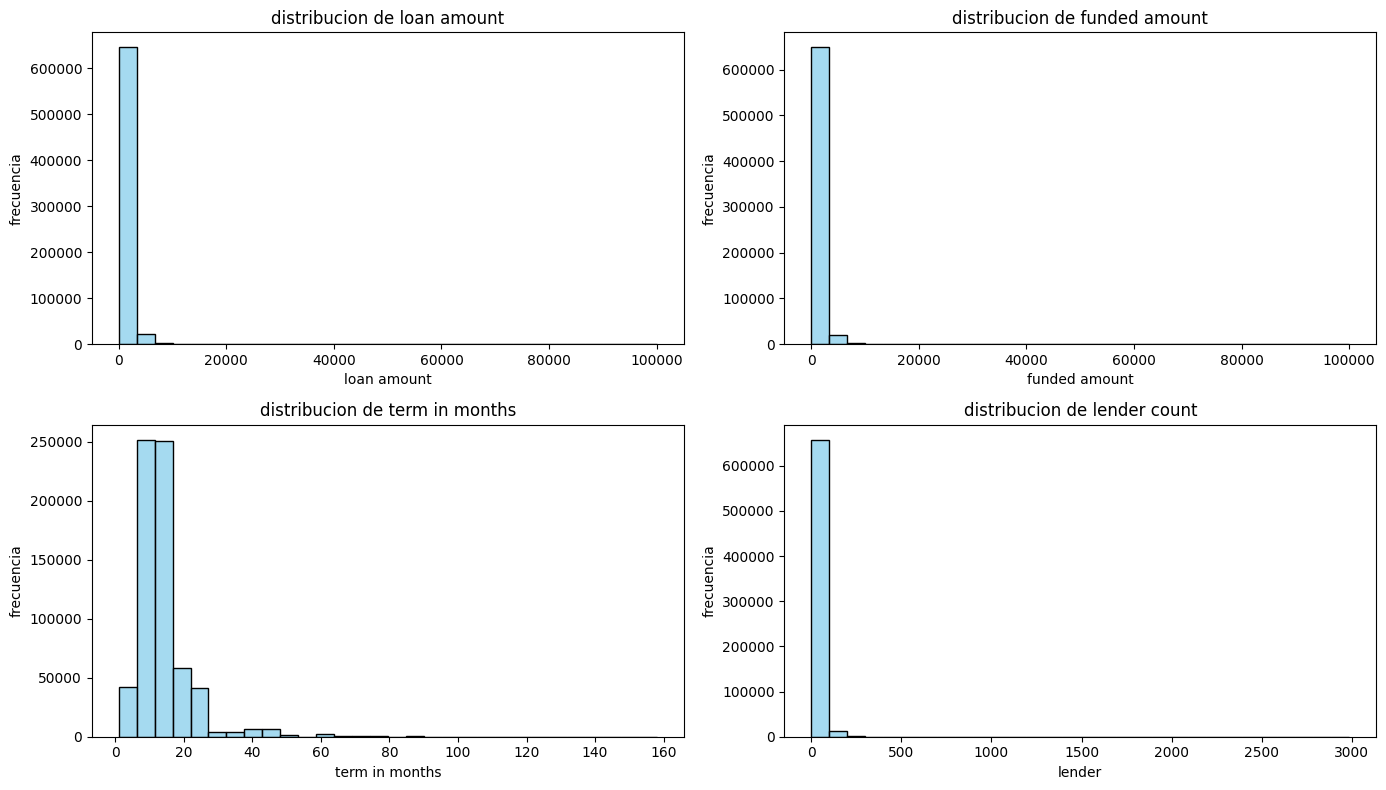

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(14,8)) # Changed to 2 rows, 2 columns to accommodate 4 plots
axes = axes.flatten()
#loan_amount
sns.histplot(df['loan_amount'],bins=30,kde=False,color='skyblue',ax=axes[0])
axes[0].set_title('distribucion de loan amount')
axes[0].set_xlabel('loan amount')
#axes[0].xlim(25,8000)
axes[0].set_ylabel('frecuencia')

#funded amount
sns.histplot(df['funded_amount'],bins=30,kde=False,color='skyblue',ax=axes[1])
axes[1].set_title('distribucion de funded amount')
axes[1].set_xlabel('funded amount')
#axes[1].xlim(25,8000)
axes[1].set_ylabel('frecuencia')

#term in months
sns.histplot(df['term_in_months'],bins=30,kde=False,color='skyblue',ax=axes[2]) # Added ax=axes[2]
axes[2].set_title('distribucion de term in months')
axes[2].set_xlabel('term in months')
#axes[2].xlim(25,8000)
axes[2].set_ylabel('frecuencia')

#lender count
sns.histplot(df['lender_count'],bins=30,kde=False,color='skyblue',ax=axes[3]) # Added ax=axes[3]
axes[3].set_title('distribucion de lender count')
axes[3].set_xlabel('lender')
#axes[3].xlim(25,8000)
axes[3].set_ylabel('frecuencia')

plt.tight_layout()
plt.show()

# graficos
##para datos discretos como paisas,sectores.etc...

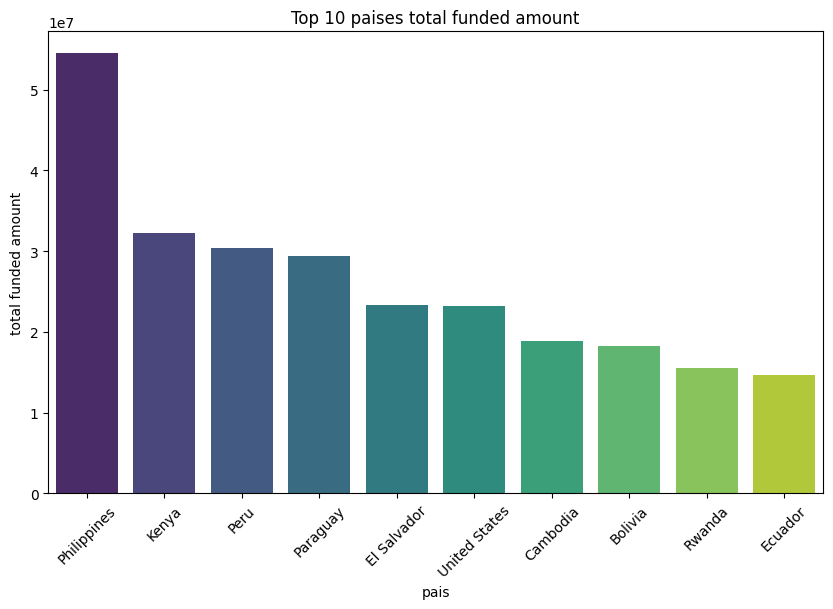

In [ ]:
country_total= kiva_loans_df.groupby('country')['funded_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=country_total.index,y=country_total.values,hue=country_total.index,palette='viridis', legend=False)
plt.title('Top 10 paises total funded amount')
plt.xlabel('pais')
plt.ylabel('total funded amount')
plt.xticks(rotation=45)
plt.show()

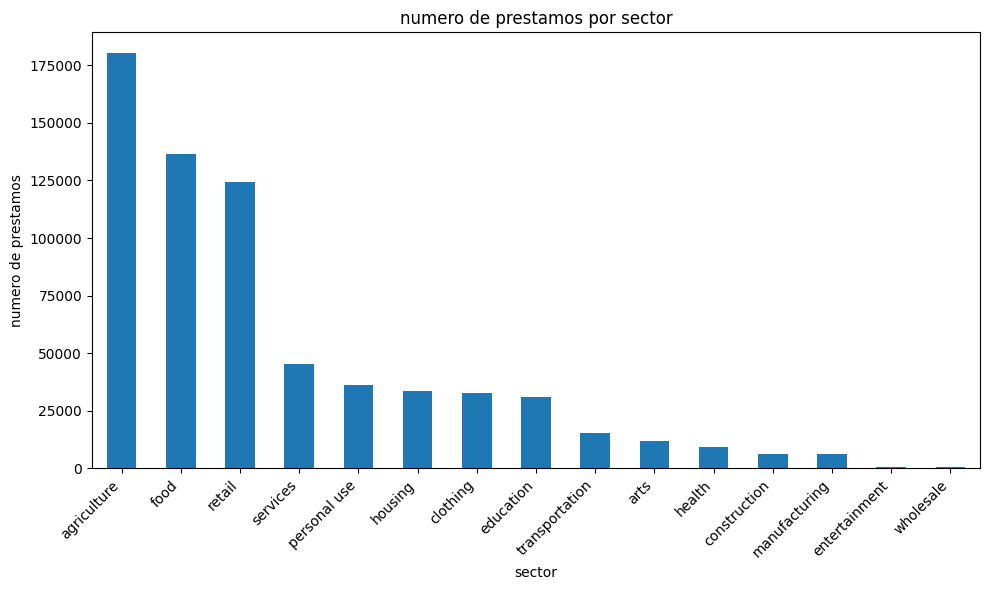

In [ ]:
cout_by_sector=kiva_loans_df['sector'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
cout_by_sector.plot(kind='bar')
plt.title('numero de prestamos por sector')
plt.xlabel('sector')
plt.ylabel('numero de prestamos')
plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()
plt.show()

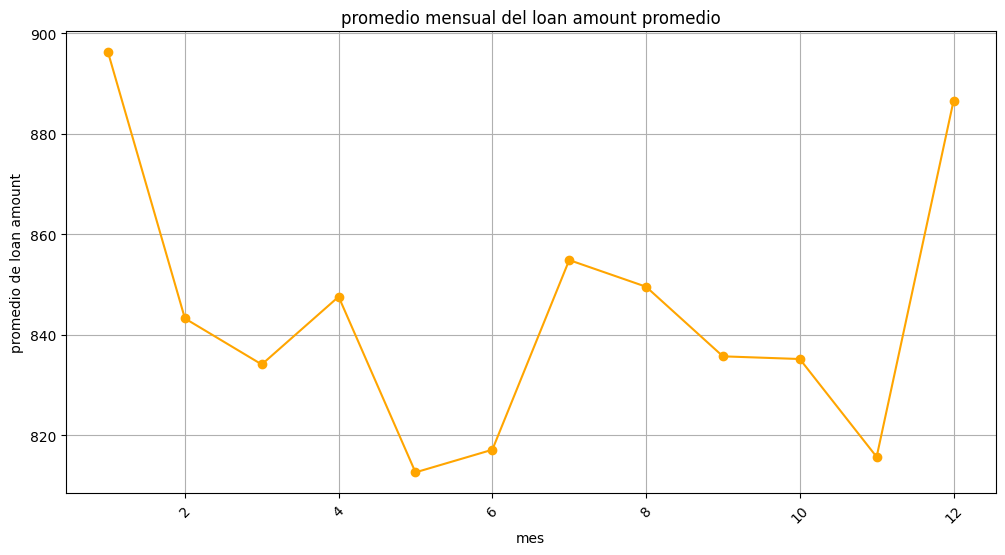

In [ ]:
#agrupar por loan_time y calcular promedio de lender_count
kiva_loans_df['month']=kiva_loans_df['posted_time'].dt.month
monthly_avr= kiva_loans_df.groupby('month')['loan_amount'].mean()

plt.figure(figsize=(12,6))
monthly_avr.plot(kind='line',marker='o',color='orange')
plt.title('promedio mensual del loan amount promedio')
plt.xlabel('mes')
plt.ylabel('promedio de loan amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
#tendencia estacional

/tmp/ipython-input-4051895640.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  kiva_loans_df_line=kiva_loans_df.groupby(pd.Grouper(key='posted_time',freq='M')).agg({'funded_amount':'sum'}).reset_index()


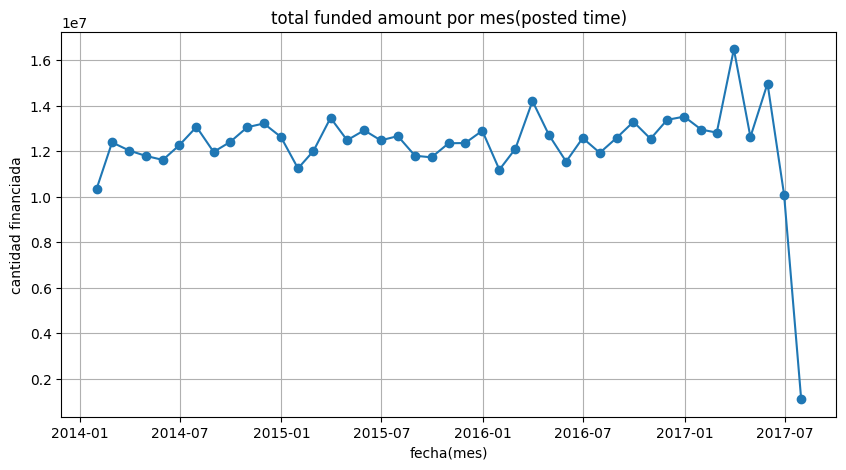

In [ ]:
kiva_loans_df['posted_time'] = pd.to_datetime(kiva_loans_df['posted_time'], errors='coerce')

#grafico de linea temporal
kiva_loans_df_line=kiva_loans_df.groupby(pd.Grouper(key='posted_time',freq='M')).agg({'funded_amount':'sum'}).reset_index()

plt.figure(figsize=(10,5))
plt.plot(kiva_loans_df_line['posted_time'],kiva_loans_df_line['funded_amount'],marker='o')
plt.title('total funded amount por mes(posted time)')
plt.xlabel('fecha(mes)')
plt.ylabel('cantidad financiada')
plt.grid(True)
plt.show()

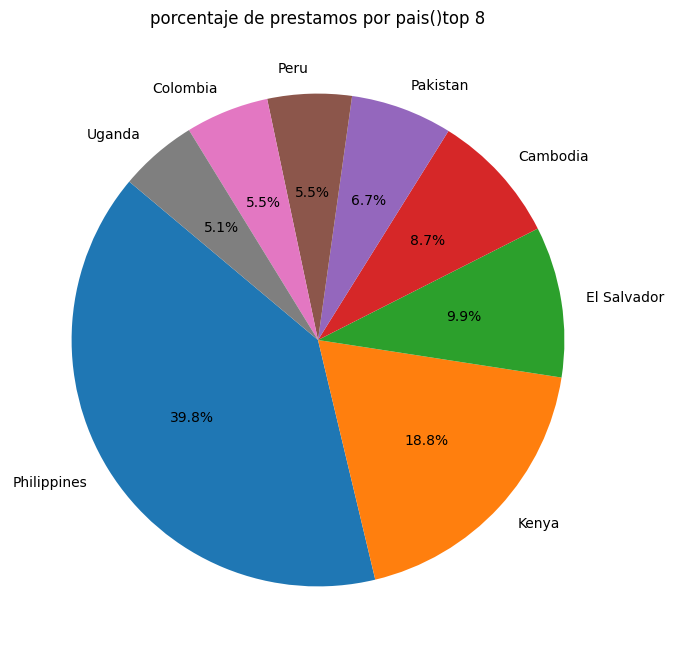

In [ ]:
top_coutries=kiva_loans_df['country'].value_counts().nlargest(8)
plt.figure(figsize=(8,8))
plt.pie(top_coutries,labels=top_coutries.index,autopct='%1.1f%%',startangle=140)
plt.title('porcentaje de prestamos por pais()top 8')
plt.show()

In [ ]:
%%capture
!pip install geodatasets

In [ ]:
import geopandas as gpd
import geodatasets
import os
import requests
import zipfile

In [ ]:
pd.set_option('display.max_columns',None)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
wold= gpd.read_file('/content/drive/MyDrive/cosas/ne_110m_admin_0_countries.shp')
wold.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,FJI,0,Fiji,FJI,0,Fiji,FJI,0,Fiji,Fiji,FJI,Fiji,None,Fiji,FJ,Republic of Fiji,None,Fiji,None,None,Fiji,None,5,1,2,2,889953.0,11,2019,5496,2019,6. Developing region,4. Lower middle income,FJ,FJ,FJ,FJI,FJI,242,242,242,FJ,FJI,23424813,23424813,Exact WOE match as country,FJI,None,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,-99,-99,Oceania,Oceania,Melanesia,East Asia & Pacific,4,4,4,-99,1,0.0,3.0,8.0,177.975427,-17.826099,1159320625,Q712,فيجي,ফিজি,Fidschi,Fiji,Fiyi,فیجی,Fidji,Φίτζι,פיג'י,फ़िजी,Fidzsi-szigetek,Fiji,Figi,フィジー,피지,Fiji,Fidżi,Fiji,Фиджи,Fiji,Fiji,Фіджі,فجی,Fiji,斐济,斐濟,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,TZA,0,Tanzania,TZA,0,Tanzania,TZA,0,Tanzania,Tanzania,TZA,Tanzania,None,Tanz.,TZ,United Republic of Tanzania,None,Tanzania,None,None,Tanzania,None,3,6,2,2,58005463.0,16,2019,63177,2019,7. Least developed region,5. Low income,TZ,TZ,TZ,TZA,TZA,834,834,834,TZ,TZA,23424973,23424973,Exact WOE match as country,TZA,None,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,-99,-99,Africa,Africa,Eastern Africa,Sub-Saharan Africa,8,8,5,-99,1,0.0,3.0,8.0,34.959183,-6.051866,1159321337,Q924,تنزانيا,তানজানিয়া,Tansania,Tanzania,Tanzania,تانزانیا,Tanzanie,Τανζανία,טנזניה,तंज़ानिया,Tanzánia,Tanzania,Tanzania,タンザニア,탄자니아,Tanzania,Tanzania,Tanzânia,Танзания,Tanzania,Tanzanya,Танзанія,تنزانیہ,Tanzania,坦桑尼亚,坦尚尼亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,SAH,0,Western Sahara,SAH,0,Western Sahara,SAH,1,W. Sahara,Western Sahara,B28,W. Sahara,None,W. Sah.,WS,Sahrawi Arab Democratic Republic,None,Western Sahara,None,Self admin.; Claimed by Morocco,Western Sahara,None,4,7,4,4,603253.0,11,2017,907,2007,7. Least develope

In [ ]:
wold['NAME']

,NAME
0,Fiji
1,Tanzania
2,W. Sahara
3,Canada
4,United States of America
...,...
172,Serbia
173,Montenegro
174,Kosovo
175,Trinidad and Tobago


In [ ]:
kiva_loans_df['country']= kiva_loans_df['country'].astype(str).str.title().str.strip()
wold['NAME'] = wold['NAME'].astype(str).str.title().str.strip()

In [ ]:
kiva_loans_df['country']

,country
0,Pakistan
1,Pakistan
2,India
3,Pakistan
4,Pakistan
...,...
671200,Paraguay
671201,Kenya
671202,Kenya
671203,Kenya


In [ ]:
con_stat=kiva_loans_df.groupby('country',as_index=False)['loan_amount'].sum()
con_stat = con_stat.rename(columns={'loan_amount':'total_loan'})

print(con_stat.index)
print(con_stat.head())

RangeIndex(start=0, stop=87, step=1)
       country  total_loan
0  Afghanistan     14000.0
1      Albania   2666500.0
2      Armenia  12915400.0
3   Azerbaijan   2888700.0
4       Belize    114025.0


In [ ]:
merged= wold.merge(con_stat,left_on='NAME',right_on='country',how='left')

<Figure size 2000x2000 with 0 Axes>

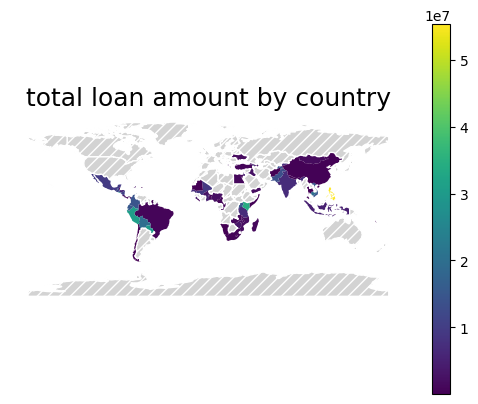

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
merged.plot(
    column='total_loan',
    cmap='viridis',
    legend=True,
    missing_kwds={
        'color':'lightgrey',
        'edgecolor':'white',
        'hatch':'///',
        'label':'no data'
    }
)
plt.title('total loan amount by country',fontsize=18)
plt.axis('off')
plt.show()


In [ ]:
import folium

In [ ]:
m = folium.Map(location=[20,0],zoom_start=2)

folium.GeoJson(
    merged,
    style_function=lambda feature: {
        'fillColor':'#gray' if feature['properties']['total_loan'] is None else '#3186cc',
        'color':'black',
        'weight':0.5,
        'fillOpacity':0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['NAME','total_loan'],
        aliases=['country:','total loan:'],
        localize=True,
        sticky=True
  )
).add_to(m)
m

In [ ]:
categories= ['micro','small','medium','large']
for cat in categories:
  df_cat = kiva_loans_df[kiva_loans_df['loan_amount_category']==cat]

  if  df_cat.empty:
    print(f'\n{cat}: (sin datos)')
    continue

  q1=df_cat['loan_amount'].quantile(0.25)
  q3=df_cat['loan_amount'].quantile(0.75)
  iqr=q3-q1

  lower_bound = q1 -1.5 * iqr
  upper_bound=q3 + 1.5 * iqr

  outliers= df_cat[(df_cat['loan_amount']<lower_bound) | (df_cat['loan_amount']>upper_bound)]
  n_outliers=len(outliers)

  print(f"\nCategoria: {cat}")
  print(f' q1: {q1}')
  print(f' q3: {q3}')
  print(f' iqr: {iqr}')
  print(f' outliers: {n_outliers}')


Categoria: micro
 q1: 200.0
 q3: 350.0
 iqr: 150.0
 outliers: 0

Categoria: small
 q1: 625.0
 q3: 1200.0
 iqr: 575.0
 outliers: 10204

Categoria: medium
 q1: 3000.0
 q3: 5000.0
 iqr: 2000.0
 outliers: 797

Categoria: large
 q1: 10000.0
 q3: 10000.0
 iqr: 0.0
 outliers: 183


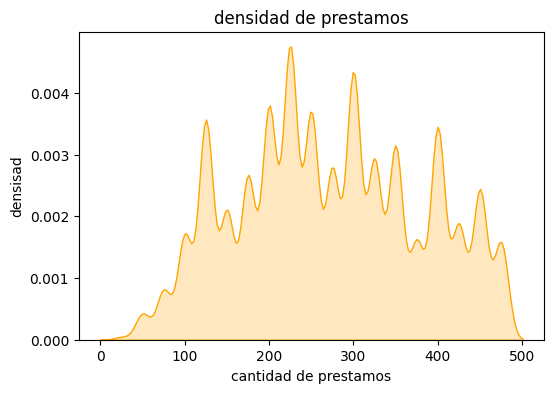

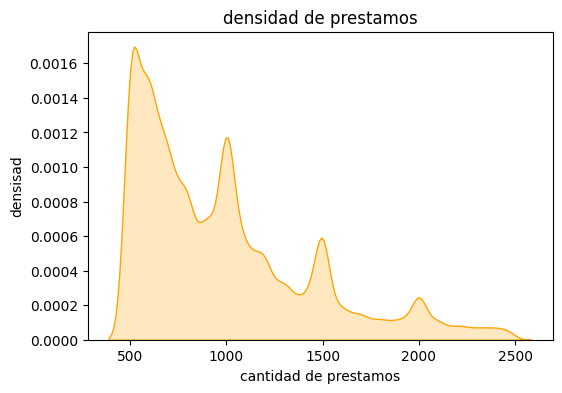

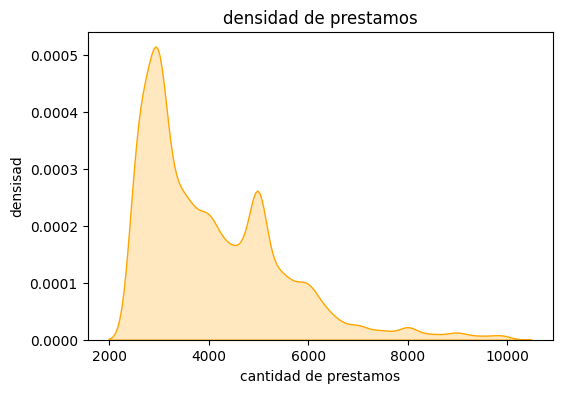

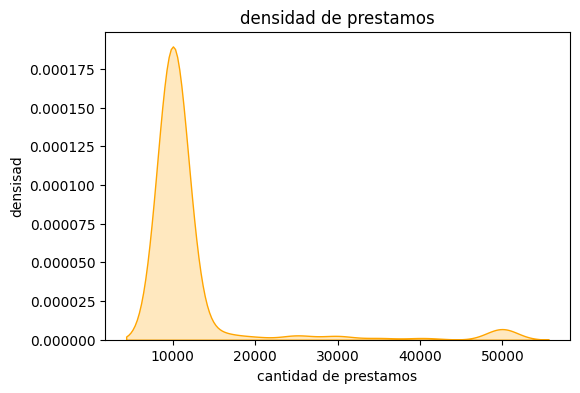

In [ ]:
import seaborn as sns

for cat in label:
  subset = kiva_loans_df[kiva_loans_df['loan_amount_category']==cat]
  plt.figure(figsize=(6,4))
  sns.kdeplot(subset['loan_amount'],fill=True,color='orange')
  plt.title(f"densidad de prestamos")
  plt.xlabel('cantidad de prestamos')
  plt.ylabel('densisad')
  plt.show()

In [ ]:
#folder = "/content/drive/MyDrive/cosas"
#os.makedirs(folder,exist_ok=True)

#kiva_loans_df.to_csv(f'{folder}/df_clean.csv',index=False)
kiva_loans_df.to_csv("df_clean.csv")
